In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
import torch
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern, DotProduct
from sklearn.decomposition import PCA
import math
import torch
from sklearn.metrics import mean_squared_error, r2_score
import gpytorch
import pandas as pd
from sklearn.preprocessing import StandardScaler
import glob

In [2]:
base_dir = "cnn-gp-outputs/"
lstm_gp_path_tas = base_dir + "lstm_eval_tas.nc"
vcae_path_tas = base_dir + "spatial_arrays_eval_tas.nc"
gp_path_tas = base_dir + "pure_gp_eval_tas.nc"
### The above are for 534-os only



In [3]:
lstm_gp = xr.open_mfdataset(lstm_gp_path_tas).sel(year=slice(2040,2100))
vcae_gp = xr.open_mfdataset(vcae_path_tas).sel(year=slice(2040,2100))
pure_gp = xr.open_mfdataset(gp_path_tas).sel(year=slice(2040,2100))
# make sure for ssp534-os we clip preds/years to be 2040-2100
# for others, it is standard to clip 2015-2100, but as we trained on ssp585 and 534-os starts off the same to 2040, we clip it there instead

In [4]:
print(lstm_gp)

<xarray.Dataset> Size: 40MB
Dimensions:                     (year: 61, lat: 144, lon: 192)
Coordinates:
  * year                        (year) int64 488B 2040 2041 2042 ... 2099 2100
  * lat                         (lat) float64 1kB -89.38 -88.12 ... 88.12 89.38
  * lon                         (lon) float64 2kB 0.9375 2.812 ... 357.2 359.1
Data variables:
    ground_truth                (year, lat, lon) float64 13MB dask.array<chunksize=(61, 144, 192), meta=np.ndarray>
    dkl_prediction              (year, lat, lon) float64 13MB dask.array<chunksize=(61, 144, 192), meta=np.ndarray>
    pattern_scaling_prediction  (year, lat, lon) float64 13MB dask.array<chunksize=(61, 144, 192), meta=np.ndarray>


In [5]:
import numpy as np
import regionmask
import matplotlib.pyplot as plt

metric = 'tas'

# 1. Reload the raw physical 2D weights matrix
global_weight_grid_2d = np.load("model_grid_area_weights.npy")

# 2. Expand it to 3D [1, Lat, Lon] so it matches your profiling broadcast shapes
weights_3d = global_weight_grid_2d[np.newaxis, :, :]
print(f"Loaded weights shape: {weights_3d.shape}") # Should display (1, 144, 192)

Loaded weights shape: (1, 144, 192)


In [6]:
plot_whole_pacific = True
ar6_regions = regionmask.defined_regions.ar6.all

In [7]:
if not plot_whole_pacific:
    # =========================================================================
    # 1. DEFINE YOUR TARGET REGION NUMBER
    # =========================================================================
    # For example, in AR6 reference regions:
    # Region ID 46 = Arctic Ocean (ARO)
    # Region ID 10 = N.S.A / Amazon Basin (NSA)
    target_region_id = 49
    
    # Get the official region object using the integer ID to extract its name/abbreviation dynamically
    
    region_info = ar6_regions[target_region_id]
    target_region_name = region_info.name
    target_region_abbrev = region_info.abbrev
    tr = f"AR6 Region {target_region_id}: {target_region_name}"
    print(f"Active Filtering Target: Region #{target_region_id} -> {target_region_name} ({target_region_abbrev})")
    
    # =========================================================================
    # 2. GENERATE THE AR6 MASK ON YOUR MODEL GRID
    # =========================================================================
    mask_2d = ar6_regions.mask(lstm_gp.lon, lstm_gp.lat)
    
    # Create a 2D boolean array by comparing directly against your integer ID
    region_mask_2d = (mask_2d == target_region_id).values  # Shape: (144, 192)
    
    # Find exactly which rows/columns contain this region so we don't plot empty space
    lat_indices = np.where(region_mask_2d.any(axis=1))[0]
    lon_indices = np.where(region_mask_2d.any(axis=0))[0]
    
    # Filter down your coordinate axes for plotting
    lat_axis_degrees = lstm_gp.lat.values[lat_indices]
    lon_axis_degrees = lstm_gp.lon.values[lon_indices]
    
    # Expand mask to 3D [Time, Lat, Lon] for clean array broadcasting
    #mask_3d = None
    mask_3d = region_mask_2d[np.newaxis, :, :]


In [8]:
if plot_whole_pacific:
    # =========================================================================
    # 2. GENERATE THE COMBINED AR6 MASK ON YOUR MODEL GRID
    # =========================================================================
    mask_2d = ar6_regions.mask(lstm_gp.lon, lstm_gp.lat)
    
    # 1. Define the list of all region IDs you want to merge (e.g., full Pacific)
    target_region_ids = [47, 48, 49]
    
    # 2. Use np.isin to capture any pixel matching any ID in your list
    region_mask_2d = np.isin(mask_2d.values, target_region_ids)  # Shape: (144, 192)
    
    # --- Dynamic Title/Label Generation for Combined Regions ---
    target_region_abbrev = "+".join([ar6_regions[rid].abbrev for rid in target_region_ids])
    target_region_name = "Combined Pacific Basin"
    tr = f"AR6 Regions {target_region_ids}: {target_region_name}"
    print(f"Active Filtering Target: {tr}")

    
    # Find exactly which rows/columns contain this combined region footprint
    lat_indices = np.where(region_mask_2d.any(axis=1))[0]
    lon_indices = np.where(region_mask_2d.any(axis=0))[0]
    
    # Filter down coordinate axes for plotting
    lat_axis_degrees = lstm_gp.lat.values[lat_indices]
    lon_axis_degrees = lstm_gp.lon.values[lon_indices]
    
    # Expand mask to 3D for clean array broadcasting
    mask_3d = region_mask_2d[np.newaxis, :, :]


Active Filtering Target: AR6 Regions [47, 48, 49]: Combined Pacific Basin


In [9]:
# =========================================================================
# 2. ADAPTIVE AREA-WEIGHTED HELPER FUNCTIONS (GLOBAL OR REGIONAL)
# =========================================================================

def compute_lat_rmse(true, pred, mask=mask_3d):
    squared_error = (true - pred) ** 2
    
    # If no mask is provided, create a global unmasked template (all True)
    if mask is None:
        local_mask_3d = np.ones((1, true.shape[1], true.shape[2]), dtype=bool)
        local_lat_indices = np.arange(true.shape[1])
    else:
        local_mask_3d = mask[np.newaxis, :, :] if mask.ndim == 2 else mask
        local_lat_indices = np.where(local_mask_3d.any(axis=(0, 2)))[0]
        
    masked_error = np.where(local_mask_3d, squared_error, np.nan)
    
    # Step A: Average across longitude columns (axis 2)
    lon_averaged_error = np.nanmean(masked_error, axis=2)
    
    # Step B: Average across time (axis 0)
    time_averaged_error = np.nanmean(lon_averaged_error, axis=0)
    
    # Slice down strictly to the relevant latitude rows
    return np.sqrt(time_averaged_error[local_lat_indices])


def compute_lat_total(true, pred, mask=mask_3d):
    abs_error = np.abs(true - pred)
    
    if mask is None:
        local_mask_3d = np.ones((1, true.shape[1], true.shape[2]), dtype=bool)
        local_lat_indices = np.arange(true.shape[1])
    else:
        local_mask_3d = mask[np.newaxis, :, :] if mask.ndim == 2 else mask
        local_lat_indices = np.where(local_mask_3d.any(axis=(0, 2)))[0]
        
    weighted_error = np.where(local_mask_3d, abs_error * weights_3d, 0.0)
    return np.sum(weighted_error[:, local_lat_indices, :], axis=(0, 2))


def compute_lon_rmse(true, pred, mask=mask_3d):
    squared_error = (true - pred) ** 2
    
    if mask is None:
        local_mask_3d = np.ones((1, true.shape[1], true.shape[2]), dtype=bool)
        local_lon_indices = np.arange(true.shape[2])
    else:
        local_mask_3d = mask[np.newaxis, :, :] if mask.ndim == 2 else mask
        local_lon_indices = np.where(local_mask_3d.any(axis=(0, 1)))[0]
        
    masked_error = np.where(local_mask_3d, squared_error, np.nan)
    active_weights = np.where(local_mask_3d, weights_3d, np.nan)
    
    # Step A: Average across time (axis 0)
    time_avg_error = np.nanmean(masked_error, axis=0)
    time_avg_weights = np.nanmean(active_weights, axis=0)
    
    # Step B: Manual area-weighted average down the latitude axis
    weighted_numerator = np.nansum(time_avg_error * time_avg_weights, axis=0)
    weighted_denominator = np.nansum(time_avg_weights, axis=0)
    
    final_lon_mse = np.where(weighted_denominator > 0, weighted_numerator / weighted_denominator, np.nan)
    return np.sqrt(final_lon_mse[local_lon_indices])


def compute_lon_total(true, pred, mask=mask_3d):
    abs_error = np.abs(true - pred)
    
    if mask is None:
        local_mask_3d = np.ones((1, true.shape[1], true.shape[2]), dtype=bool)
        local_lon_indices = np.arange(true.shape[2])
    else:
        local_mask_3d = mask[np.newaxis, :, :] if mask.ndim == 2 else mask
        local_lon_indices = np.where(local_mask_3d.any(axis=(0, 1)))[0]
        
    weighted_error = np.where(local_mask_3d, abs_error * weights_3d, 0.0)
    return np.sum(weighted_error[:, :, local_lon_indices], axis=(0, 1))


In [10]:


# =========================================================================
# 3. EXECUTE METRIC PROFILING
# =========================================================================
# --- Latitudinal Extraction ---
gp_lat_rmse = compute_lat_rmse(lstm_gp.ground_truth.values, lstm_gp.dkl_prediction.values)
baseline_lat_rmse = compute_lat_rmse(lstm_gp.ground_truth.values, lstm_gp.pattern_scaling_prediction.values)
vcae_lat_rmse = compute_lat_rmse(vcae_gp.ground_truth.values, vcae_gp.dkl_prediction.values)
pure_lat_rmse = compute_lat_rmse(pure_gp.ground_truth.values, pure_gp.dkl_prediction.values)

gp_lat_total = compute_lat_total(lstm_gp.ground_truth.values, lstm_gp.dkl_prediction.values)
baseline_lat_total = compute_lat_total(lstm_gp.ground_truth.values, lstm_gp.pattern_scaling_prediction.values)
vcae_lat_total = compute_lat_total(vcae_gp.ground_truth.values, vcae_gp.dkl_prediction.values)
pure_lat_total = compute_lat_total(pure_gp.ground_truth.values, pure_gp.dkl_prediction.values)

# --- Longitudinal Extraction ---
gp_lon_rmse = compute_lon_rmse(lstm_gp.ground_truth.values, lstm_gp.dkl_prediction.values)
baseline_lon_rmse = compute_lon_rmse(lstm_gp.ground_truth.values, lstm_gp.pattern_scaling_prediction.values)
vcae_lon_rmse = compute_lon_rmse(vcae_gp.ground_truth.values, vcae_gp.dkl_prediction.values)
pure_lon_rmse = compute_lon_rmse(pure_gp.ground_truth.values, pure_gp.dkl_prediction.values)

gp_lon_total = compute_lon_total(lstm_gp.ground_truth.values, lstm_gp.dkl_prediction.values)
baseline_lon_total = compute_lon_total(lstm_gp.ground_truth.values, lstm_gp.pattern_scaling_prediction.values)
vcae_lon_total = compute_lon_total(vcae_gp.ground_truth.values, vcae_gp.dkl_prediction.values)
pure_lon_total = compute_lon_total(pure_gp.ground_truth.values, pure_gp.dkl_prediction.values)

error_unit_str = "(°C)" if metric == "tas" else "(kg m-2 s-1)"


/tmp/ipykernel_11769/2940591981.py:19: RuntimeWarning: Mean of empty slice
  lon_averaged_error = np.nanmean(masked_error, axis=2)
/tmp/ipykernel_11769/2940591981.py:22: RuntimeWarning: Mean of empty slice
  time_averaged_error = np.nanmean(lon_averaged_error, axis=0)
/tmp/ipykernel_11769/2940591981.py:56: RuntimeWarning: Mean of empty slice
  time_avg_error = np.nanmean(masked_error, axis=0)
/tmp/ipykernel_11769/2940591981.py:57: RuntimeWarning: Mean of empty slice
  time_avg_weights = np.nanmean(active_weights, axis=0)
/tmp/ipykernel_11769/2940591981.py:63: RuntimeWarning: invalid value encountered in divide
  final_lon_mse = np.where(weighted_denominator > 0, weighted_numerator / weighted_denominator, np.nan)


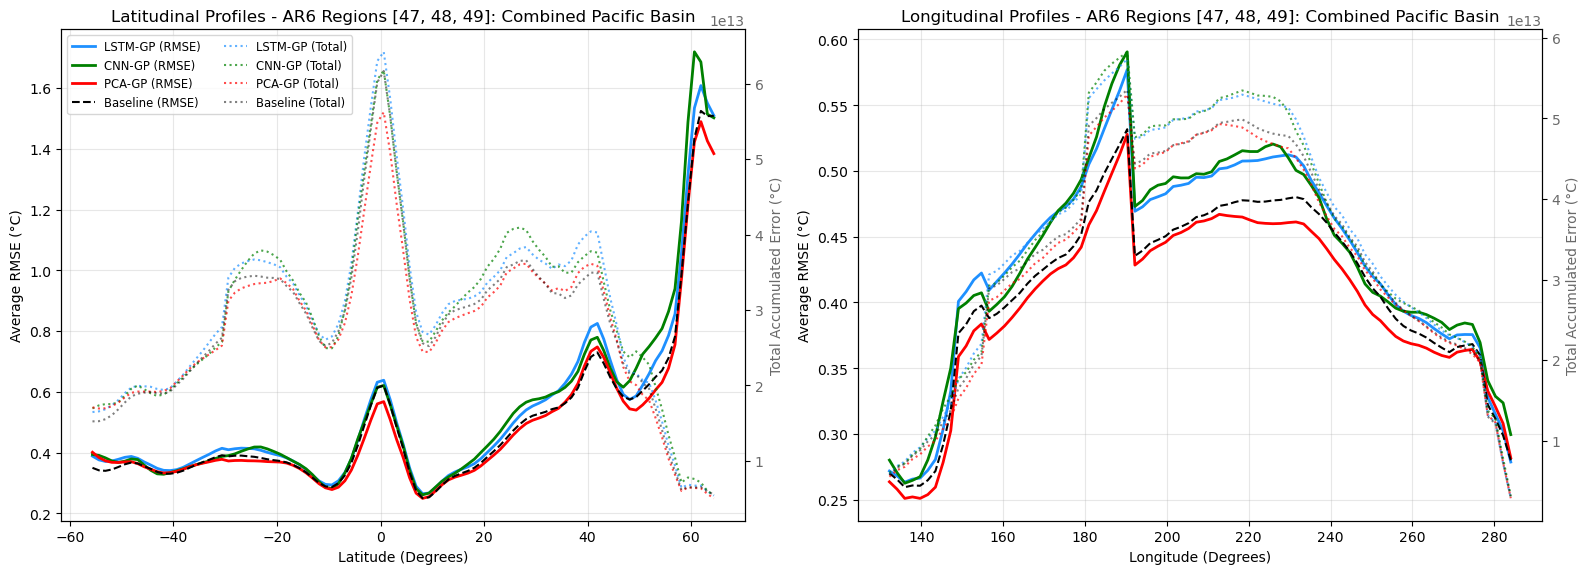

In [11]:
import matplotlib.pyplot as plt

def plots(tr=tr, cap_y=False):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # =========================================================================
    # DYNAMIC AXIS COORDINATE SELECTION
    # =========================================================================
    # Latitudinal check: identify if data is the full globe or a region subset
    if gp_lat_total.shape[0] == 144:
        active_lat_axis = lstm_gp.lat.values
        lat_title_suffix = "Global"
    else:
        active_lat_axis = lat_axis_degrees
        lat_title_suffix = tr

    # Longitudinal check: identify if data is the full globe or a region subset
    if gp_lon_total.shape[0] == 192 and mask_3d is None:
        active_lon_axis = lstm_gp.lon.values
        lon_title_suffix = "Global"
    else:
        active_lon_axis = lon_axis_degrees
        lon_title_suffix = tr

    # =========================================================================
    # 1. LATITUDINAL PROFILE (LEFT)
    # =========================================================================
    ax1_left = axes[0]
    ax1_right = ax1_left.twinx()  # Create the right-hand Y-axis
    
    # --- Left Y-Axis: Average RMSE ---
    line1 = ax1_left.plot(active_lat_axis, gp_lat_rmse, label='LSTM-GP (RMSE)', color='dodgerblue', linewidth=2)
    line2 = ax1_left.plot(active_lat_axis, vcae_lat_rmse, label='CNN-GP (RMSE)', color='green', linewidth=2)
    line3 = ax1_left.plot(active_lat_axis, pure_lat_rmse, label='PCA-GP (RMSE)', color='red', linewidth=2)
    line4 = ax1_left.plot(active_lat_axis, baseline_lat_rmse, label='Baseline (RMSE)', color='black', linestyle='--')
    
    ax1_left.set_xlabel('Latitude (Degrees)')
    ax1_left.set_ylabel(f'Average RMSE {error_unit_str}', color='black')
    ax1_left.tick_params(axis='y', labelcolor='black')
    ax1_left.grid(True, alpha=0.3)
    
    # --- Right Y-Axis: Total Accumulated Error ---
    line5 = ax1_right.plot(active_lat_axis, gp_lat_total, color='dodgerblue', linestyle=':', alpha=0.7, label='LSTM-GP (Total)')
    line6 = ax1_right.plot(active_lat_axis, vcae_lat_total, color='green', linestyle=':', alpha=0.7, label='CNN-GP (Total)')
    line7 = ax1_right.plot(active_lat_axis, pure_lat_total, color='red', linestyle=':', alpha=0.7, label='PCA-GP (Total)')
    line8 = ax1_right.plot(active_lat_axis, baseline_lat_total, color='black', linestyle=':', alpha=0.5, label='Baseline (Total)')
    
    ax1_right.set_ylabel(f'Total Accumulated Error {error_unit_str}', color='dimgray')
    ax1_right.tick_params(axis='y', labelcolor='dimgray')
    
    # --- Combined Legend for Subplot 1 ---
    lines_lat = line1 + line2 + line3 + line4 + line5 + line6 + line7 + line8
    labels_lat = [l.get_label() for l in lines_lat]
    ax1_left.legend(lines_lat, labels_lat, loc='upper left', fontsize='small', ncol=2)
    ax1_left.set_title(f'Latitudinal Profiles - {lat_title_suffix}')
    
    
    # =========================================================================
    # 2. LONGITUDINAL PROFILE (RIGHT)
    # =========================================================================
    ax2_left = axes[1]
    ax2_right = ax2_left.twinx()  # Create the right-hand Y-axis
    
    # --- Left Y-Axis: Average RMSE ---
    ax2_left.plot(active_lon_axis, gp_lon_rmse, color='dodgerblue', linewidth=2)
    ax2_left.plot(active_lon_axis, vcae_lon_rmse, color='green', linewidth=2)
    ax2_left.plot(active_lon_axis, pure_lon_rmse, color='red', linewidth=2)
    ax2_left.plot(active_lon_axis, baseline_lon_rmse, color='black', linestyle='--')
    
    ax2_left.set_xlabel('Longitude (Degrees)')
    ax2_left.set_ylabel(f'Average RMSE {error_unit_str}', color='black')
    ax2_left.tick_params(axis='y', labelcolor='black')
    ax2_left.grid(True, alpha=0.3)
    
    # --- Right Y-Axis: Total Accumulated Error ---
    ax2_right.plot(active_lon_axis, gp_lon_total, color='dodgerblue', linestyle=':', alpha=0.7)
    ax2_right.plot(active_lon_axis, vcae_lon_total, color='green', linestyle=':', alpha=0.7)
    ax2_right.plot(active_lon_axis, pure_lon_total, color='red', linestyle=':', alpha=0.7)
    ax2_right.plot(active_lon_axis, baseline_lon_total, color='black', linestyle=':', alpha=0.5)
    
    ax2_right.set_ylabel(f'Total Accumulated Error {error_unit_str}', color='dimgray')
    ax2_right.tick_params(axis='y', labelcolor='dimgray')
    
    ax2_left.set_title(f'Longitudinal Profiles - {lon_title_suffix}')

    if cap_y:
        ax1_left.set_ylim(top=3)
    
    plt.tight_layout()
    plt.show()

# Call the function safely
plots()
